<a href="https://colab.research.google.com/github/sanskrutimishra2307-droid/Machine_Vision_Lab/blob/main/Mv_05_016.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

Saving images.jpg to images.jpg


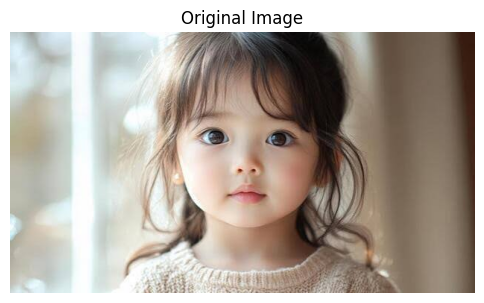

In [3]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

In [5]:
def detect_faces_eyes(image):

    output = image.copy()

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(40,40)
    )

    face_count = 0
    eye_count = 0

    for (x,y,w,h) in faces:

        face_count += 1

        cv2.rectangle(output,(x,y),(x+w,y+h),(0,255,0),2)

        roi_gray = gray[y:y+h,x:x+w]
        roi_color = output[y:y+h,x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        eye_count += len(eyes)

        for(ex,ey,ew,eh) in eyes:
            cv2.rectangle(
                roi_color,
                (ex,ey),
                (ex+ew,ey+eh),
                (255,0,0),
                2
            )

    return output, face_count, eye_count

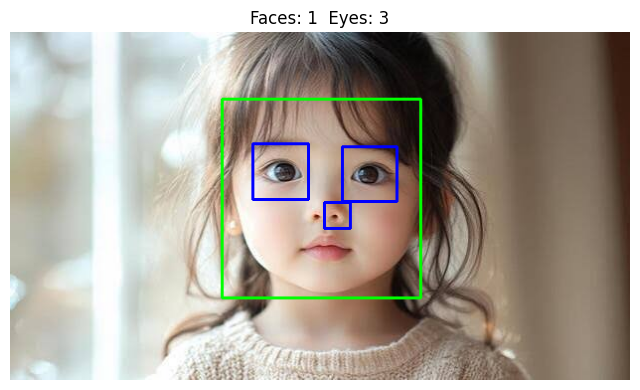

In [6]:
detected, faces, eyes = detect_faces_eyes(img)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
plt.title(f"Faces: {faces}  Eyes: {eyes}")
plt.axis("off")
plt.show()

In [7]:
bright = cv2.convertScaleAbs(img, alpha=1.2, beta=70)

dark = cv2.convertScaleAbs(img, alpha=0.5, beta=-40)

high_contrast = cv2.convertScaleAbs(img, alpha=2.0, beta=20)

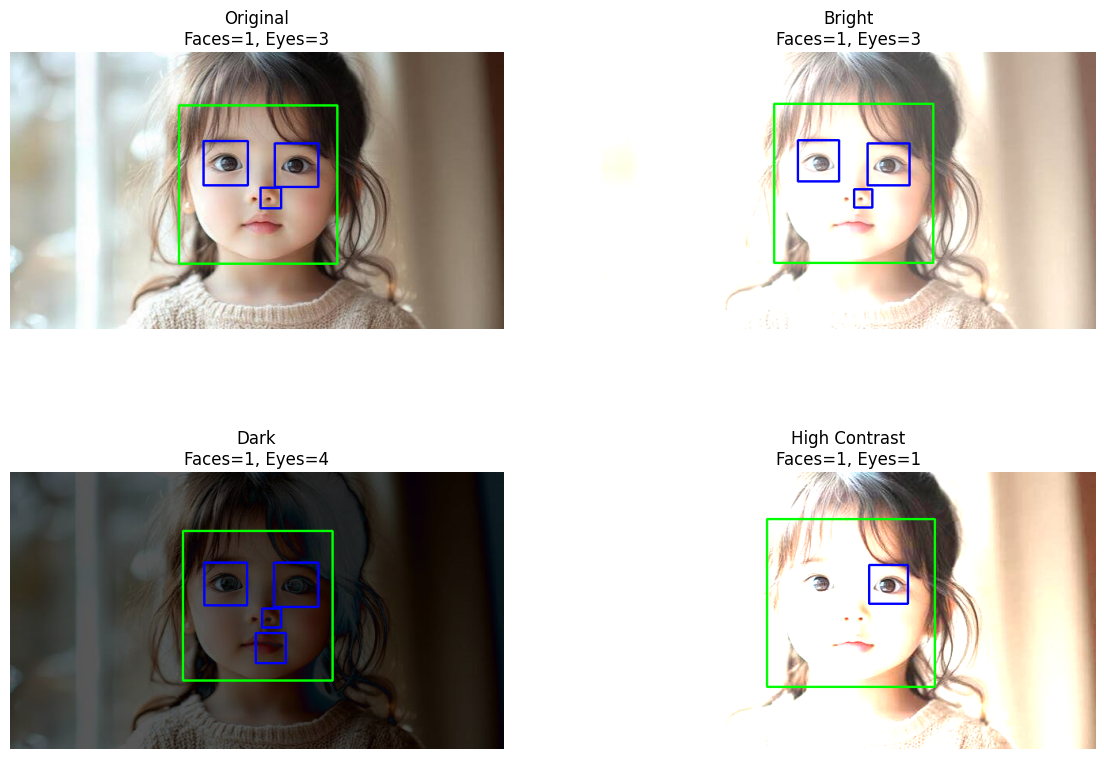

In [8]:
conditions = {
    "Original": img,
    "Bright": bright,
    "Dark": dark,
    "High Contrast": high_contrast
}

results = []

plt.figure(figsize=(14,10))

i = 1

for name,image in conditions.items():

    detected, face_count, eye_count = detect_faces_eyes(image)

    results.append([name, face_count, eye_count])

    plt.subplot(2,2,i)
    plt.imshow(cv2.cvtColor(detected, cv2.COLOR_BGR2RGB))
    plt.title(f"{name}\nFaces={face_count}, Eyes={eye_count}")
    plt.axis("off")

    i += 1

plt.show()

In [9]:
import pandas as pd

df = pd.DataFrame(
    results,
    columns=[
        "Lighting Condition",
        "Faces Detected",
        "Eyes Detected"
    ]
)

print(df)

  Lighting Condition  Faces Detected  Eyes Detected
0           Original               1              3
1             Bright               1              3
2               Dark               1              4
3      High Contrast               1              1


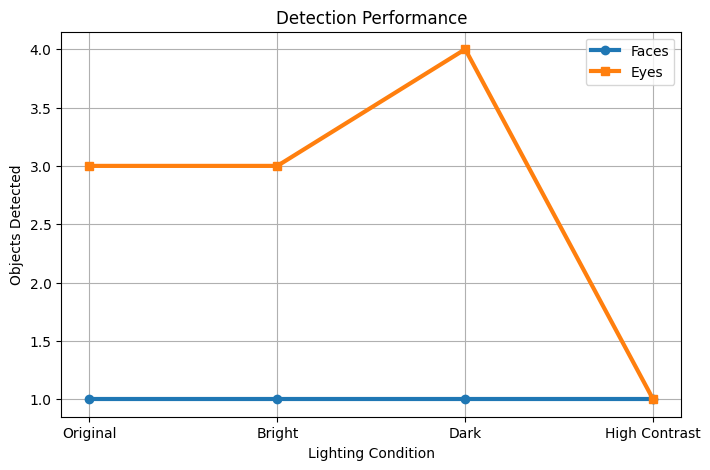

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Lighting Condition"],
    df["Faces Detected"],
    marker='o',
    linewidth=3,
    label="Faces"
)

plt.plot(
    df["Lighting Condition"],
    df["Eyes Detected"],
    marker='s',
    linewidth=3,
    label="Eyes"
)

plt.xlabel("Lighting Condition")
plt.ylabel("Objects Detected")
plt.title("Detection Performance")

plt.grid(True)
plt.legend()

plt.show()

In [11]:
from google.colab.patches import cv2_imshow

cap = cv2.VideoCapture(0)

ret, frame = cap.read()

if ret:
    detected, faces, eyes = detect_faces_eyes(frame)

    print("Faces:", faces)
    print("Eyes :", eyes)

    cv2_imshow(detected)

cap.release()